# Score do Comprador

In [1]:
# Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
# from kneed import KneeLocator
import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
# from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [2]:
%pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Importação do dataset
# from google.colab import drive
# drive.mount('/content/drive')

df_cp = pd.read_csv('data/dataset_compradores_sintetico_2000.csv')
df_cp.head(3)

,comprador_id,comprador_nome,liquidez_corrente,liquidez_seca,endividamento_total,divida_liquida_ebitda,margem_ebitda,ebitda,fluxo_caixa_operacional,dias_atraso_medio,...,qtd_processos_tributarios,qtd_processos_civeis,qtd_reclamacoes_publicas,score_reclameaqui,qtd_noticias_negativas,tempo_medio_retirada,tempo_medio_entrega,taxa_avarias,cumprimento_volume_contratado,qtd_contratos_quebrados
0,1,Comprador_0001,1.69,1.08,0.56,3.42,0.27,75354522.87,98318795.07,4.4,...,4,3,6,3.3,1,2.5,1.6,0.064,0.87,0
1,2,Comprador_0002,3.36,1.04,0.74,1.28,0.26,67249507.15,12464869.18,5.4,...,1,4,6,8.7,2,9.9,6.6,0.007,0.85,0
2,3,Comprador_0003,2.72,2.76,0.71,4.43,0.08,36054628.59,36728306.81,39.1,...,1,2,6,3.2,4,6.6,11.0,0.134,0.91,1


In [4]:
import openpyxl
openpyxl.__version__

'3.1.5'

In [5]:
criterios_n1 = pd.read_excel(
    "data/AHP_Criterios_Comprador_Preenchido.xlsx",
    sheet_name="Critérios_Nivel1",
    index_col=0
)

# pesos_criterios = ahp_weights_from_matrix(criterios_n1)
print(f"Shape of criterios_n1: {criterios_n1.shape}")
criterios_n1.head()

Shape of criterios_n1: (6, 7)


,Saúde Financeira,Capacidade de Pagamento,Jurídico & Regulação,Reputação & Governança,Operação & Logística,Relacionamento com Produtores,Peso
Saúde Financeira,1.000000,3.000000,5.000000,7,7.000000,7,0.4661
Capacidade de Pagamento,0.333333,1.000000,3.000000,7,5.000000,5,0.2593
Jurídico & Regulação,0.200000,0.333333,1.000000,3,3.000000,3,0.1213
Reputação & Governança,0.142857,0.142857,0.333333,1,0.333333,1,0.0407
Operação & Logística,0.142857,0.200000,0.333333,3,1.000000,1,0.0628


In [6]:
def ahp_weights_from_matrix(df):
    matrix = df.values.astype(float)
    eigvals, eigvecs = np.linalg.eig(matrix)
    max_index = np.argmax(eigvals.real)
    weights = eigvecs[:, max_index].real
    weights = weights / weights.sum()
    return pd.Series(weights, index=df.index)

In [7]:
df_cp= df_cp.drop('comprador_id', axis=1)
df_cp= df_cp.drop('comprador_nome', axis=1)

In [8]:
num_cols = df_cp.select_dtypes(include=['number']).columns.tolist()
cat_cols = df_cp.select_dtypes(include=['object']).columns.tolist()

In [9]:
# # Pipeline para colunas numéricas
# num_papiline = Pipeline([
#                 ('imputer', SimpleImputer(strategy='median')),
#                 ('scaler', StandardScaler())
# ])

#             # Pipeline para colunas categóricas
# cat_papiline = Pipeline([
#                 ('imputer', SimpleImputer(strategy='most_frequent')),
#                 ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', num_papiline, num_cols),
#         ('cat', cat_papiline, cat_cols)
#      ],
#     remainder='passthrough'
# )



In [10]:
# Papiline de Pré-processamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer

num_papiline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_papiline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
    ('num', num_papiline, num_cols),
    ('cat', cat_papiline, cat_cols)
])

In [11]:
# 3. Transformar o DataFrame COMPLETO (X)
X_preprocessed_array = preprocessor.fit_transform(df_cp)

In [12]:
# 4. Obter os nomes das colunas após o OneHotEncoding
feature_names = num_cols
if cat_cols:
    feature_names.extend(list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)))

In [13]:
# 5. Converter o array NumPy de volta para um DataFrame Pandas
df_preprocessed_features = pd.DataFrame(
                X_preprocessed_array,
                columns=feature_names,
                index=df_cp.index
)

In [14]:
df_cp = df_preprocessed_features.copy()
df_cp.head()

,liquidez_corrente,liquidez_seca,endividamento_total,divida_liquida_ebitda,margem_ebitda,ebitda,fluxo_caixa_operacional,dias_atraso_medio,inadimplencia_percentual,qtd_processos_trabalhistas,qtd_processos_tributarios,qtd_processos_civeis,qtd_reclamacoes_publicas,score_reclameaqui,qtd_noticias_negativas,tempo_medio_retirada,tempo_medio_entrega,taxa_avarias,cumprimento_volume_contratado,qtd_contratos_quebrados
0,-0.420113,-0.814100,0.273063,0.560658,0.856233,-0.452705,0.546143,-1.462925,-1.791895,-0.056098,3.076769,0.009501,0.452124,-1.113225,-0.720154,-1.167882,-1.568560,-0.251111,0.223861,-1.029483
1,1.550975,-0.867426,1.054485,-1.094969,0.738156,-0.592566,-1.429058,-1.405504,-1.791895,0.619777,0.019870,0.603337,0.452124,1.434255,-0.013774,1.665017,-0.328523,-1.580669,-0.005446,-1.029483
2,0.795588,1.425589,0.924248,1.342052,-1.387223,-1.130871,-0.870840,0.529598,-0.087477,-0.056098,0.019870,-0.584335,0.452124,-1.160401,1.398985,0.401697,0.762709,1.381678,0.682474,-0.022161
3,0.347077,-0.854095,-1.202955,0.436873,1.564693,0.349562,0.956724,-0.038874,-1.691635,1.295652,3.076769,-1.178171,0.007994,-0.499943,-0.013774,-1.129599,-0.229320,1.498306,-1.037327,-0.022161
4,-1.175500,-0.774106,-1.202955,-1.149125,0.265850,-0.099062,0.114075,1.006195,1.616941,0.619777,-0.999097,-0.584335,0.007994,-0.216890,-0.720154,-0.823340,-0.824538,1.101772,0.338514,0.985161


In [15]:
Col_Financeira = ['liquidez_corrente', 'liquidez_seca', 'endividamento_total','divida_liquida_ebitda', 'margem_ebitda', 'ebitda']
Col_FPagamento = ['fluxo_caixa_operacional', 'dias_atraso_medio', 'inadimplencia_percentual']
Col_Juridico = ['qtd_processos_trabalhistas', 'qtd_processos_tributarios','qtd_processos_civeis']
Col_Reputacao = ['qtd_reclamacoes_publicas', 'score_reclameaqui','qtd_noticias_negativas']
Col_Logistica = ['tempo_medio_retirada','tempo_medio_entrega','taxa_avarias','cumprimento_volume_contratado']
Col_Relacionamento = ['qtd_contratos_quebrados']

def Cal_pesos(df):
    Peso_Financeira = float (df[Col_Financeira].mean()) * float(criterios_n1.Peso["Saúde Financeira"])
    Peso_FPagamento = float (df[Col_FPagamento].mean()) * float(criterios_n1.Peso["Capacidade de Pagamento"])
    Peso_Juridico = float (df[Col_Juridico].mean()) * float(criterios_n1.Peso["Jurídico & Regulação"])
    Peso_Reputacao = float (df[Col_Reputacao].mean()) * float(criterios_n1.Peso["Reputação & Governança"])
    Peso_Logistica = float (df[Col_Logistica].mean()) * float(criterios_n1.Peso["Operação & Logística"])
    Peso_Relacionamento = float (df[Col_Relacionamento].mean()) * float(criterios_n1.Peso["Relacionamento com Produtores"])

    peso_bruto = Peso_Financeira + Peso_FPagamento + Peso_Juridico + Peso_Reputacao + Peso_Logistica + Peso_Relacionamento

    return peso_bruto

In [16]:
# criar a coluna Peso_bruto com a função Cal_peso
df_cp['Peso_bruto'] = df_cp.apply(Cal_pesos, axis=1)
df_cp.head()

,liquidez_corrente,liquidez_seca,endividamento_total,divida_liquida_ebitda,margem_ebitda,ebitda,fluxo_caixa_operacional,dias_atraso_medio,inadimplencia_percentual,qtd_processos_trabalhistas,...,qtd_processos_civeis,qtd_reclamacoes_publicas,score_reclameaqui,qtd_noticias_negativas,tempo_medio_retirada,tempo_medio_entrega,taxa_avarias,cumprimento_volume_contratado,qtd_contratos_quebrados,Peso_bruto
0,-0.420113,-0.814100,0.273063,0.560658,0.856233,-0.452705,0.546143,-1.462925,-1.791895,-0.056098,...,0.009501,0.452124,-1.113225,-0.720154,-1.167882,-1.568560,-0.251111,0.223861,-1.029483,-0.224761
1,1.550975,-0.867426,1.054485,-1.094969,0.738156,-0.592566,-1.429058,-1.405504,-1.791895,0.619777,...,0.603337,0.452124,1.434255,-0.013774,1.665017,-0.328523,-1.580669,-0.005446,-1.029483,-0.318139
2,0.795588,1.425589,0.924248,1.342052,-1.387223,-1.130871,-0.870840,0.529598,-0.087477,-0.056098,...,-0.584335,0.452124,-1.160401,1.398985,0.401697,0.762709,1.381678,0.682474,-0.022161,0.149796
3,0.347077,-0.854095,-1.202955,0.436873,1.564693,0.349562,0.956724,-0.038874,-1.691635,1.295652,...,-1.178171,0.007994,-0.499943,-0.013774,-1.129599,-0.229320,1.498306,-1.037327,-0.022161,0.090018
4,-1.175500,-0.774106,-1.202955,-1.149125,0.265850,-0.099062,0.114075,1.006195,1.616941,0.619777,...,-0.584335,0.007994,-0.216890,-0.720154,-0.823340,-0.824538,1.101772,0.338514,0.985161,-0.090392


In [17]:
df_cp.Peso_bruto.describe()

count    2.000000e+03
mean    -5.551115e-18
std      2.572008e-01
min     -7.763739e-01
25%     -1.754296e-01
50%     -7.931160e-03
75%      1.733977e-01
max      7.426993e-01
Name: Peso_bruto, dtype: float64

In [18]:
# Normalizar a coluna Peso_bruto
scaler = MinMaxScaler()

df_cp['Peso_bruto'] = scaler.fit_transform(df_cp[['Peso_bruto']])

In [19]:
df_cp.Peso_bruto.describe()

count    2000.000000
mean        0.511084
std         0.169314
min         0.000000
25%         0.395599
50%         0.505863
75%         0.625231
max         1.000000
Name: Peso_bruto, dtype: float64

In [20]:
def CreateScore(cluster):
    if cluster <= 0.25:
        return 1
    elif cluster > 0.25 and cluster <= 0.50:
        return 2
    elif cluster > 0.50 and cluster <= 0.75:
        return 3
    elif cluster > 0.75 and cluster <= 1:
        return 4
    else:
        return None

In [21]:
# Criar nova coluna 'Score'
df_cp['Score'] = df_cp['Peso_bruto'].apply(CreateScore)

In [22]:
df_cp.Score.describe()

count    2000.000000
mean        2.539000
std         0.726459
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: Score, dtype: float64

In [23]:
df_cp = df_cp.drop('Peso_bruto', axis=1)

In [24]:
df_cp.columns

Index(['liquidez_corrente', 'liquidez_seca', 'endividamento_total',
       'divida_liquida_ebitda', 'margem_ebitda', 'ebitda',
       'fluxo_caixa_operacional', 'dias_atraso_medio',
       'inadimplencia_percentual', 'qtd_processos_trabalhistas',
       'qtd_processos_tributarios', 'qtd_processos_civeis',
       'qtd_reclamacoes_publicas', 'score_reclameaqui',
       'qtd_noticias_negativas', 'tempo_medio_retirada', 'tempo_medio_entrega',
       'taxa_avarias', 'cumprimento_volume_contratado',
       'qtd_contratos_quebrados', 'Score'],
      dtype='object')

/tmp/ipykernel_9989/3347076053.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


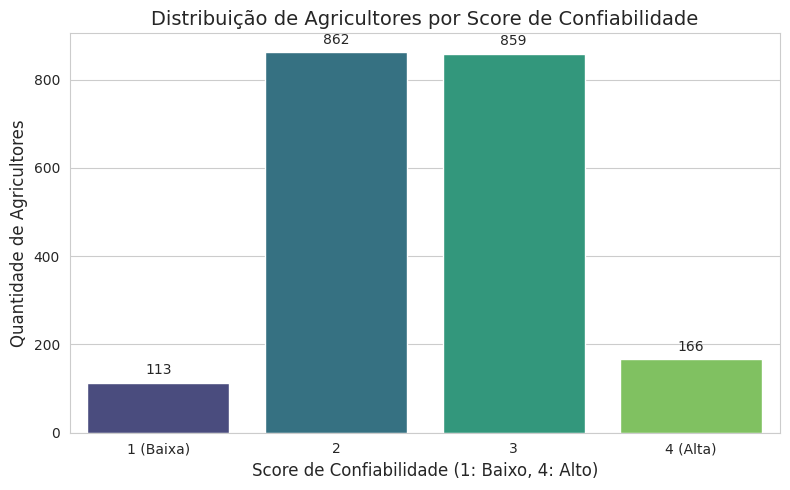

In [25]:
# 1. Obter os dados de contagem (o resultado do seu value_counts())
contagem_scores = df_cp['Score'].value_counts().sort_index()

# 2. Configurações para o gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
ax = sns.barplot(
    x=contagem_scores.index,  # Nomes das barras (1, 2, 3, 4)
    y=contagem_scores.values, # Altura das barras (Contagem de Agricultores)
    palette="viridis"
)

# 4. Adicionar rótulos de dados (o número exato de agricultores em cima de cada barra)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

# 5. Adicionar títulos e rótulos
plt.title('Distribuição de Agricultores por Score de Confiabilidade', fontsize=14)
plt.xlabel('Score de Confiabilidade (1: Baixo, 4: Alto)', fontsize=12)
plt.ylabel('Quantidade de Agricultores', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['1 (Baixa)', '2', '3', '4 (Alta)'])
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

In [26]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]1/2 [imbalanced-learn]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [27]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
import pandas as pd

# 1. Separar features e target
X = df_cp.drop(columns=["Score"])
y = df_cp["Score"]

# 2. Split treino/teste mantendo desbalanceamento real no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Escolher o método de oversampling
# opção A → SMOTE (mais comum e estável)
# oversampler = SMOTE(sampling_strategy={1: 2000, 4: 2000}, random_state=42)

# opção B → ADASYN (mais focado em exemplos difíceis)
oversampler = ADASYN(sampling_strategy={1: 670, 4: 670}, random_state=42)

# 4. Aplicar oversampling apenas no treino
X_train_res, y_train_res = oversampler.fit_resample(X_train, y_train)

# 5. Reconstruir DataFrame balanceado de treino (opcional)
df_train_balanced = pd.concat(
    [pd.DataFrame(X_train_res, columns=X_train.columns),
     pd.DataFrame(y_train_res, columns=["Score"])],
    axis=1
)

# 6. Ver nova distribuição
print("Distribuição no treino antes:\n", y_train.value_counts())
print("\nDistribuição no treino depois:\n", y_train_res.value_counts())


Distribuição no treino antes:
 Score
2    690
3    687
4    133
1     90
Name: count, dtype: int64

Distribuição no treino depois:
 Score
2    690
3    687
1    664
4    642
Name: count, dtype: int64


/tmp/ipykernel_9989/3497766011.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


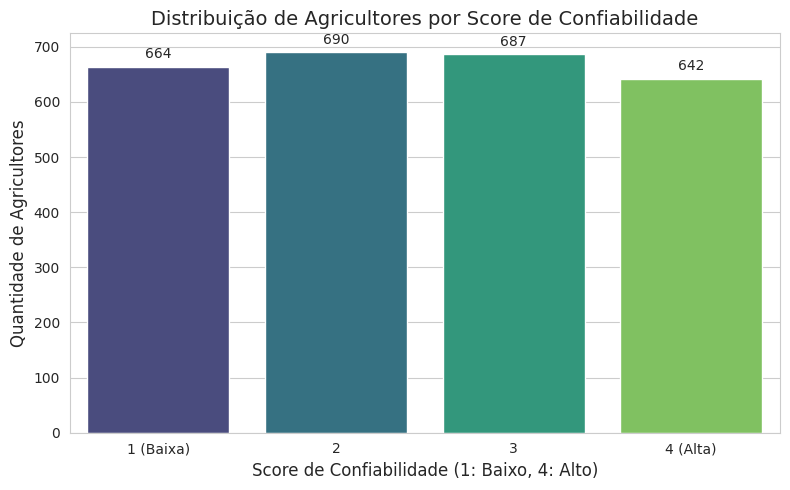

In [28]:
# 1. Obter os dados de contagem (o resultado do seu value_counts())
contagem_scores = df_train_balanced['Score'].value_counts().sort_index()

# 2. Configurações para o gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
ax = sns.barplot(
    x=contagem_scores.index,  # Nomes das barras (1, 2, 3, 4)
    y=contagem_scores.values, # Altura das barras (Contagem de Agricultores)
    palette="viridis"
)

# 4. Adicionar rótulos de dados (o número exato de agricultores em cima de cada barra)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

# 5. Adicionar títulos e rótulos
plt.title('Distribuição de Agricultores por Score de Confiabilidade', fontsize=14)
plt.xlabel('Score de Confiabilidade (1: Baixo, 4: Alto)', fontsize=12)
plt.ylabel('Quantidade de Agricultores', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['1 (Baixa)', '2', '3', '4 (Alta)'])
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

In [29]:
df_classfy = df_train_balanced.copy()
df_class = df_train_balanced.copy()

In [30]:
# Criando colunas com as médias das categorias
df_classfy['mean_financeira'] = df_classfy[Col_Financeira].mean(axis=1)
df_classfy['mean_pagamento'] = df_classfy[Col_FPagamento].mean(axis=1)
df_classfy['mean_juridico'] = df_classfy[Col_Juridico].mean(axis=1)
df_classfy['mean_reputacao'] = df_classfy[Col_Reputacao].mean(axis=1)
df_classfy['mean_logistica'] = df_classfy[Col_Logistica].mean(axis=1)
df_classfy['mean_relacionamento'] = df_classfy[Col_Relacionamento].mean(axis=1)

colunas_medias = ['mean_financeira', 'mean_pagamento', 'mean_juridico', 'mean_reputacao', 'mean_logistica', 'mean_relacionamento']

# Agora defina o X novamente (sem o Score)
df_media = df_classfy[colunas_medias]
# X = df_classfy.drop(columns=['Score'])
X = df_media.copy()

In [31]:
df_classfy.columns

Index(['liquidez_corrente', 'liquidez_seca', 'endividamento_total',
       'divida_liquida_ebitda', 'margem_ebitda', 'ebitda',
       'fluxo_caixa_operacional', 'dias_atraso_medio',
       'inadimplencia_percentual', 'qtd_processos_trabalhistas',
       'qtd_processos_tributarios', 'qtd_processos_civeis',
       'qtd_reclamacoes_publicas', 'score_reclameaqui',
       'qtd_noticias_negativas', 'tempo_medio_retirada', 'tempo_medio_entrega',
       'taxa_avarias', 'cumprimento_volume_contratado',
       'qtd_contratos_quebrados', 'Score', 'mean_financeira', 'mean_pagamento',
       'mean_juridico', 'mean_reputacao', 'mean_logistica',
       'mean_relacionamento'],
      dtype='object')

In [32]:


# === 1. Features (X) e Target (y) ===
# X = df_classfy.drop(columns=['Score'])
y = df_class['Score']

# === 2. Separar treino e teste com estratificação ===
# 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Conferindo os tamanhos
print("Tamanho conjunto de treino :", X_train.shape, y_train.shape)
print("Tamanho conjunto de teste  :", X_test.shape,  y_test.shape)

# Distribuição das classes para checar estratificação
print("\nDistribuição classes - treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição classes - teste:")
print(y_test.value_counts(normalize=True))


Tamanho conjunto de treino : (1878, 6) (1878,)
Tamanho conjunto de teste  : (805, 6) (805,)

Distribuição classes - treino:
Score
2    0.257188
3    0.256124
1    0.247604
4    0.239084
Name: proportion, dtype: float64

Distribuição classes - teste:
Score
2    0.257143
3    0.255901
1    0.247205
4    0.239752
Name: proportion, dtype: float64


In [33]:
# Verificando se há valores nulos
print("Valores nulos em X_train:", X_train.isnull().sum().sum())
print("Valores nulos em X_test:", X_test.isnull().sum().sum())

# Verificando tipos de dados
print("\nTipos de dados em X_train:")
print(X_train.dtypes.value_counts())

Valores nulos em X_train: 0
Valores nulos em X_test: 0

Tipos de dados em X_train:
float64    6
Name: count, dtype: int64


In [34]:
# from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Importar Random forest
from sklearn.ensemble import RandomForestClassifier

# Criar e treinar o modelo
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
# Fazer previsões
y_pred = model.predict(X_test)

In [36]:
# Avaliar os resultados com as métricas
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\n Relatório de classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 86.34%

 Relatório de classificação:
              precision    recall  f1-score   support

           1       0.91      0.97      0.94       199
           2       0.81      0.80      0.81       207
           3       0.81      0.76      0.78       206
           4       0.91      0.93      0.92       193

    accuracy                           0.86       805
   macro avg       0.86      0.87      0.86       805
weighted avg       0.86      0.86      0.86       805



In [37]:
# Criar e treinar o modelo
model_RF = RandomForestClassifier(random_state=42)
model_RF.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# Fazer previsões
y_pred_RF = model_RF.predict(X_test)

In [39]:
# Avaliar os resultados do RandomForest
print(f"Acurácia: {accuracy_score(y_test, y_pred_RF):.2%}")
print("\n Relatório de classificação:")
print(classification_report(y_test, y_pred_RF))

Acurácia: 93.79%

 Relatório de classificação:
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       199
           2       0.89      0.93      0.91       207
           3       0.93      0.84      0.89       206
           4       0.96      0.98      0.97       193

    accuracy                           0.94       805
   macro avg       0.94      0.94      0.94       805
weighted avg       0.94      0.94      0.94       805



In [40]:
import joblib

# Para salvar o modelo
joblib.dump(model_RF, 'classificador_comprador.pkl')

['classificador_comprador.pkl']

In [41]:
df_classfy.to_csv("df_classify_comprador.csv", index=False)

In [42]:
df_train = df_classfy[colunas_medias]

df_train.to_csv("df_classify_comprador_sem_score.csv", index=False)